In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import PIL
import random
import copy

In [2]:
def parseLUND(filename):
    events = [] #all events
    import urllib.request
    url = 'https://userweb.jlab.org/~kenjo/rho_test_bin.lund'
    with urllib.request.urlopen(url) as f:
        while True:
            headerline = f.readline().decode('utf-8')
            #recognize file end
            if headerline == '':
                break
            #skip empty lines
            headerline = headerline.strip()
            if headerline == '':
                continue
            #split header
            headerfields = headerline.split()
            #extract info
            try:
                n_particles   = int(headerfields[0])
                target_mass   = int(headerfields[1])
                target_atomic = int(headerfields[2])
                target_pol    = float(headerfields[3])
                spin_z        = float(headerfields[4])
                beam_type     = int(headerfields[5])
                beam_energy   = float(headerfields[6])
                nucleon_id    = int(headerfields[7])
                process_id    = int(headerfields[8])
                event_weight  = float(headerfields[9])
            #exclude and show errors
            except (IndexError, ValueError) as e:
                print(f"Warning: could not parse header line: '{header_line}'")
                print(f"  Reason: {e}")
                continue
            if beam_type not in (11, 22):
                print(f"Warning: unexpected beam type {beam_type} "
                      f"(expected 11=electron or 22=photon)")
            #read particles
            particles = []
            for i in range(n_particles):
                particle_line = f.readline().decode('utf-8')
                particle_line = particle_line.strip()
                #skip blank particles
                if particle_line == '':
                    i -= 1  # don't count this as a particle line
                    continue
                #split into fields
                fields = particle_line.split()
                #parse fields
                try:
                    particle = {
                        'index'         : int(fields[0]),
                        'lifetime'      : float(fields[1]),
                        'type'          : int(fields[2]),
                        'pdg_id'        : int(fields[3]),
                        'parent_index'  : int(fields[4]),
                        'daughter_index': int(fields[5]),
                        'px'            : float(fields[6]),
                        'py'            : float(fields[7]),
                        'pz'            : float(fields[8]),
                        'energy'        : float(fields[9]),
                        'mass'          : float(fields[10]),
                        'vx'            : float(fields[11]),
                        'vy'            : float(fields[12]),
                        }
                    particles.append(particle)
                except (IndexError, ValueError) as e:
                    print(f"Warning: could not parse particle line: '{particle_line}'")
                    print(f"  Reason: {e}")
                    continue
            event = {
                'n_particles'  : n_particles,
                'target_mass'  : target_mass,
                'target_atomic': target_atomic,
                'target_pol'   : target_pol,
                'spin_z'       : spin_z,
                'beam_type'    : beam_type,
                'beam_energy'  : beam_energy,
                'nucleon_id'   : nucleon_id,
                'process_id'   : process_id,
                'event_weight' : event_weight,
                'particles'    : particles,
            }
            events.append(event)
    return events



#check parsing accuracy
def verify_parser(all_events, n_print=2):
    print(f"Total events parsed: {len(all_events)}\n")
    for event_idx in range(min(n_print, len(all_events))):
        event = all_events[event_idx]
        print(f"--- Event {event_idx + 1} ---")
        print(f"  Particles in header : {event['n_particles']}")
        print(f"  Particles parsed    : {len(event['particles'])}")
        print(f"  Target (A, Z)       : ({event['target_mass']}, {event['target_atomic']})")
        print(f"  Target polarization : {event['target_pol']}")
        print(f"  Spin Z              : {event['spin_z']}")
        print(f"  Beam type           : {event['beam_type']} "
              f"({'electron' if event['beam_type'] == 11 else 'photon'})")
        print(f"  Beam energy         : {event['beam_energy']} GeV")
        print(f"  Nucleon ID          : {event['nucleon_id']} "
              f"({'proton' if event['nucleon_id'] == 2212 else 'neutron'})")
        print(f"  Process ID          : {event['process_id']}")
        print(f"  Event weight        : {event['event_weight']}")
        #check particle counts match
        if event['n_particles'] != len(event['particles']):
            print("error: particle count mismatch")
        print("  Particle list:")
        for p in event['particles']:
            print(f"    idx={p['index']:3d}  "
                  f"PDG={p['pdg_id']:6d}  "
                  f"type={p['type']}  "
                  f"E={p['energy']:.4f} GeV  "
                  f"mass={p['mass']:.4f} GeV/c^2  "
                  f"px={p['px']:.4f}  py={p['py']:.4f}  pz={p['pz']:.4f}  "
                  f"vx={p['vx']:.4f} cm  vy={p['vy']:.4f} cm  "
                  f"lifetime={p['lifetime']:.4f} ns")
        print()
 

#sanity check
if __name__ == '__main__':
    filename = 'https://userweb.jlab.org/~kenjo/rho_test_bin.lund'
    print(f"Parsing {filename} ...")
    all_events = parseLUND(filename)
    #check first two elements
    verify_parser(all_events, n_print=2)

Parsing https://userweb.jlab.org/~kenjo/rho_test_bin.lund ...
Total events parsed: 100000

--- Event 1 ---
  Particles in header : 4
  Particles parsed    : 4
  Target (A, Z)       : (1, 1)
  Target polarization : 0.0
  Spin Z              : 1.0
  Beam type           : 11 (electron)
  Beam energy         : 10.6041 GeV
  Nucleon ID          : 2212 (proton)
  Process ID          : 0
  Event weight        : 0.00276186
  Particle list:
    idx=  1  PDG=    11  type=1  E=2.3281 GeV  mass=0.0005 GeV/c^2  px=-0.6253  py=1.0771  pz=1.9670  vx=0.0000 cm  vy=0.0000 cm  lifetime=0.0000 ns
    idx=  2  PDG=   211  type=1  E=5.9468 GeV  mass=0.1396 GeV/c^2  px=0.1619  py=-0.1562  pz=5.9409  vx=0.0000 cm  vy=0.0000 cm  lifetime=0.0000 ns
    idx=  3  PDG=  -211  type=1  E=1.6991 GeV  mass=0.1396 GeV/c^2  px=0.4924  py=-0.3339  pz=1.5854  vx=0.0000 cm  vy=0.0000 cm  lifetime=0.0000 ns
    idx=  4  PDG=  2212  type=1  E=1.5683 GeV  mass=0.9383 GeV/c^2  px=-0.0290  py=-0.5870  pz=1.1108  vx=0.0000 cm  

Events processed : 100000
Events used      : 100000
Events skipped   : 0


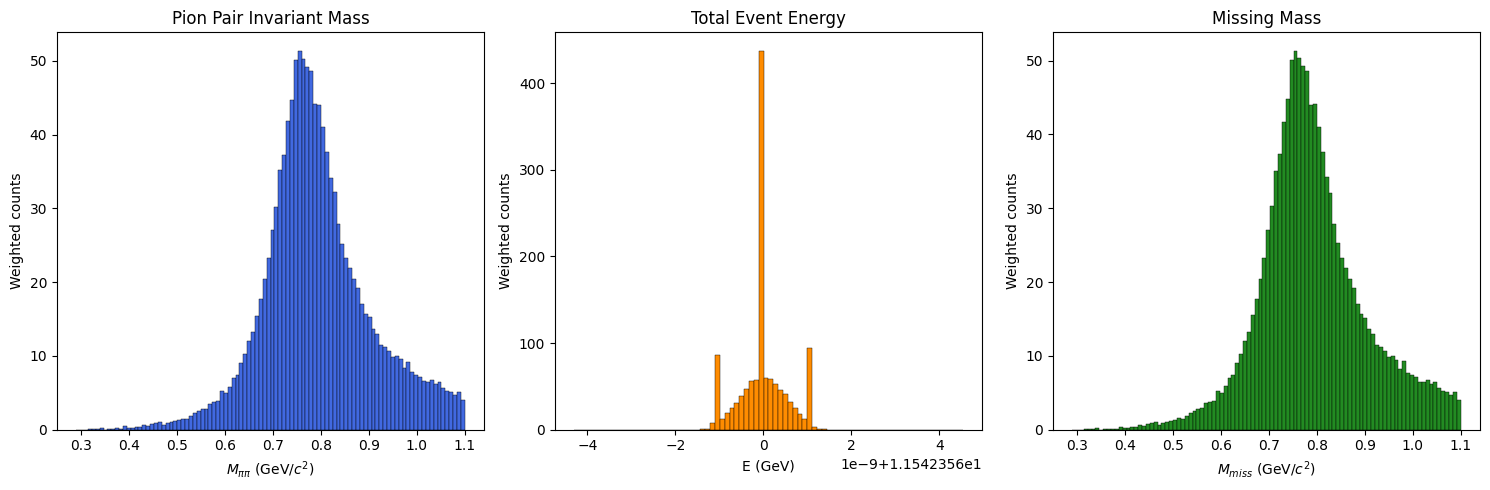

Histograms saved to histograms.png


In [3]:
MASS_PROTON   = 0.938272
MASS_ELECTRON = 0.000511
MASS_PION     = 0.139570
MASS_PI0      = 0.134977
PDG_ELECTRON  = 11
PDG_PROTON    = 2212
PDG_PIP       = 211
PDG_PIM       = -211
PDG_PI0       = 111


#PID
def identify_particles(event):
    final_electron = None
    final_proton   = None
    pions          = []

    for p in event['particles']:
        pdg = p['pdg_id']

        if pdg == PDG_ELECTRON:
            final_electron = p
        elif pdg == PDG_PROTON:
            final_proton = p
        elif pdg in (PDG_PIP, PDG_PIM, PDG_PI0):
            pions.append(p)

    return {
        'beam_electron' : None,
        'target_proton' : None,
        'final_electron': final_electron,
        'final_proton'  : final_proton,
        'pions'         : pions,
    }

#invariant mass
def invariant_mass(p1, p2):
    E  = p1['energy'] + p2['energy']
    px = p1['px']     + p2['px']
    py = p1['py']     + p2['py']
    pz = p1['pz']     + p2['pz']
    m2 = E**2 - px**2 - py**2 - pz**2
    #filter out complex mass
    if m2 < 0:
        print(f"Warning: negative M^2 = {m2:.6f}, skipping event.")
        return None
    return math.sqrt(m2)
 
#sum of total energy
def total_event_energy(event):
    total = 0.0
    for p in event['particles']:
        total += p['energy']
    return total
 
#missing mass
def missing_mass(event, final_electron, final_proton):
    beam_energy = event['beam_energy']
    #initial state
    e0_E  = beam_energy
    e0_px = 0.0
    e0_py = 0.0
    e0_pz = math.sqrt(max(beam_energy**2 - MASS_ELECTRON**2, 0.0))
    p0_E  = MASS_PROTON
    p0_px = 0.0
    p0_py = 0.0
    p0_pz = 0.0
    #final state
    e1_E  = final_electron['energy']
    e1_px = final_electron['px']
    e1_py = final_electron['py']
    e1_pz = final_electron['pz']
    p1_E  = final_proton['energy']
    p1_px = final_proton['px']
    p1_py = final_proton['py']
    p1_pz = final_proton['pz']
    #missing four-momentum
    miss_E  = e0_E  + p0_E  - e1_E  - p1_E
    miss_px = e0_px + p0_px - e1_px - p1_px
    miss_py = e0_py + p0_py - e1_py - p1_py
    miss_pz = e0_pz + p0_pz - e1_pz - p1_pz
    mmiss2 = miss_E**2 - miss_px**2 - miss_py**2 - miss_pz**2
    #filter out imaginary mass
    if mmiss2 < 0:
        print(f"Warning: negative Mmiss^2 = {mmiss2:.6f}, skipping event.")
        return None
    return math.sqrt(mmiss2)


#process all events
def process_events(all_events):
    pion_inv_masses = []
    total_energies  = []
    missing_masses  = []
    weights         = []
    skipped = 0
    for event_idx, event in enumerate(all_events):
        parts = identify_particles(event)
        #only run if calculation will not fail
        if len(parts['pions']) < 2:
            skipped += 1
            continue
        if parts['final_electron'] is None:
            skipped += 1
            continue
        if parts['final_proton'] is None:
            skipped += 1
            continue
        m_pipi = invariant_mass(parts['pions'][0], parts['pions'][1])
        if m_pipi is None:
            skipped += 1
            continue
        e_total = total_event_energy(event)
        mm = missing_mass(
            event,
            parts['final_electron'],
            parts['final_proton']
        )
        if mm is None:
            skipped += 1
            continue
        #collect results of complete data
        pion_inv_masses.append(m_pipi)
        total_energies.append(e_total)
        missing_masses.append(mm)
        weights.append(event['event_weight'])
    print(f"Events processed : {len(all_events)}")
    print(f"Events used      : {len(pion_inv_masses)}")
    print(f"Events skipped   : {skipped}")
    return pion_inv_masses, total_energies, missing_masses, weights


#plotting (moment of truth)
def plot_histograms(pion_inv_masses, total_energies, missing_masses, weights):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
    #pion pair invariant mass plot
    axes[0].hist(pion_inv_masses, bins=100, weights=weights,
                 color='royalblue', edgecolor='black', linewidth=0.3)
    axes[0].set_xlabel('$M_{\\pi\\pi}$ (GeV/$c^2$)')
    axes[0].set_ylabel('Weighted counts')
    axes[0].set_title('Pion Pair Invariant Mass')
 
    #energy plot
    axes[1].hist(total_energies, bins=80, weights=weights,
                 color='darkorange', edgecolor='black', linewidth=0.3)
    axes[1].set_xlabel('E (GeV)')
    axes[1].set_ylabel('Weighted counts')
    axes[1].set_title('Total Event Energy')
 
    #missing mass plot
    axes[2].hist(missing_masses, bins=100, weights=weights,
                 color='forestgreen', edgecolor='black', linewidth=0.3)
    axes[2].set_xlabel('$M_{miss}$ (GeV/$c^2$)')
    axes[2].set_ylabel('Weighted counts')
    axes[2].set_title('Missing Mass')
 
    plt.tight_layout()
    plt.savefig('histograms.png', dpi=150)
    plt.show()
    print("Histograms saved to histograms.png")
 
#run the file
if __name__ == '__main__':
    pion_inv_masses, total_energies, missing_masses, weights = process_events(all_events)
    plot_histograms(pion_inv_masses, total_energies, missing_masses, weights)

Events processed : 100000
Events used      : 100000
Events skipped   : 0


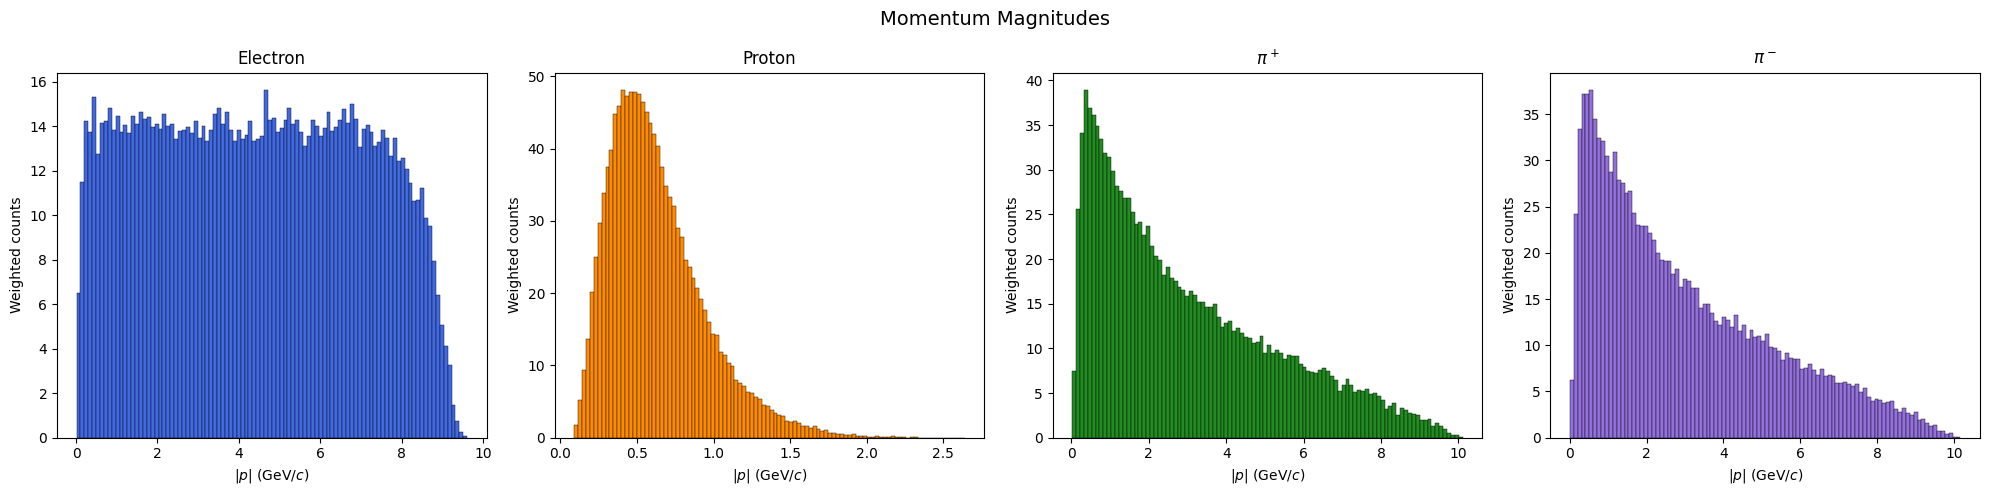

Saved momenta.png


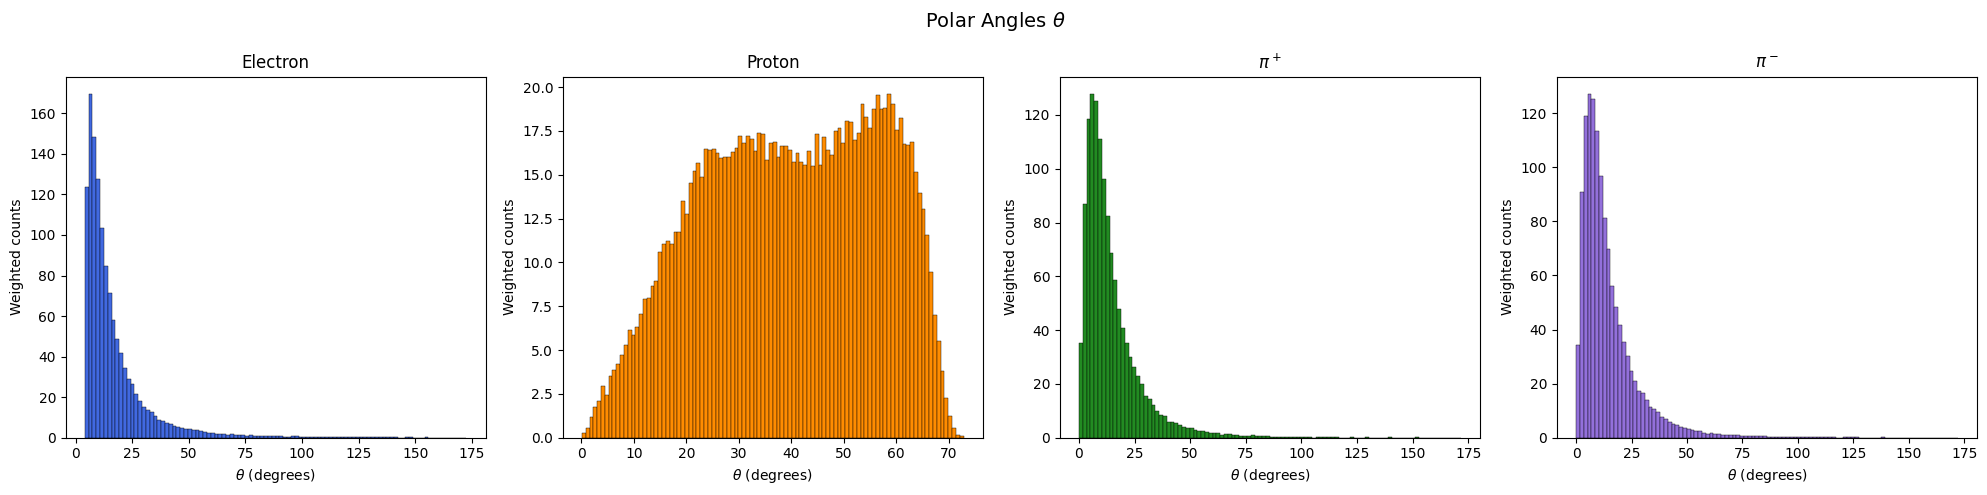

Saved polar_angles.png


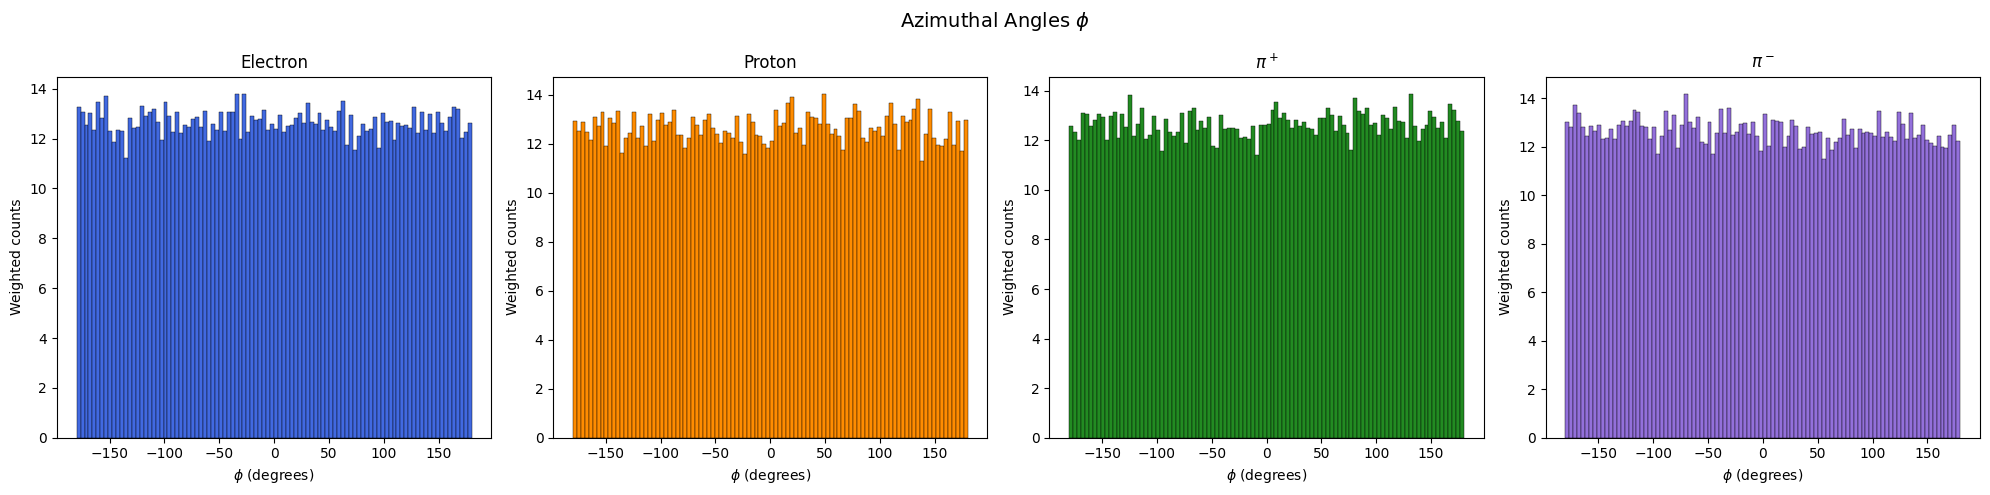

Saved azimuthal_angles.png


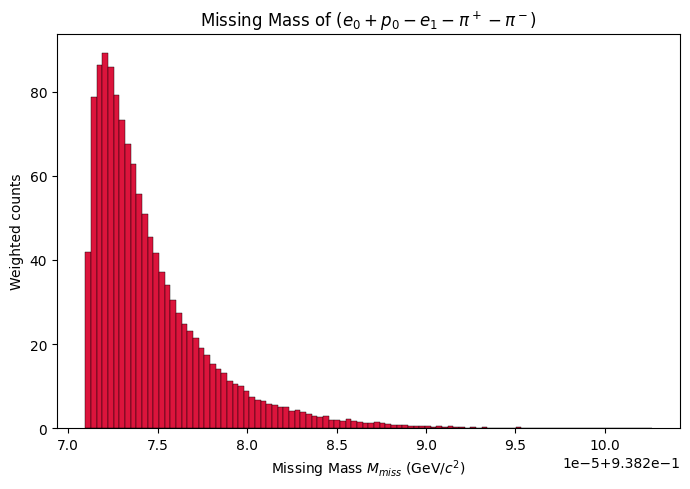

Saved missing_mass_new.png


In [4]:
def process_extended(all_events):
    p_electron  = []
    p_proton    = []
    p_pip       = []
    p_pim       = []

    theta_electron  = []
    theta_proton    = []
    theta_pip       = []
    theta_pim       = []

    phi_electron  = []
    phi_proton    = []
    phi_pip       = []
    phi_pim       = []

    missing_masses_new = []

    weights  = []
    skipped  = 0

    for event in all_events:
        parts = identify_particles(event)
        #skips incomplete entries
        if parts['final_electron'] is None:
            skipped += 1
            continue
        if parts['final_proton'] is None:
            skipped += 1
            continue
        if len(parts['pions']) < 2:
            skipped += 1
            continue

        #identify pi+ and pi-
        pip = None
        pim = None
        for pion in parts['pions']:
            if pion['pdg_id'] == PDG_PIP:
                pip = pion
            elif pion['pdg_id'] == PDG_PIM:
                pim = pion
        if pip is None or pim is None:
            skipped += 1
            continue

        e1 = parts['final_electron']
        p1 = parts['final_proton']

        #compute magnitudes and angles
        def pmag(p):
            return math.sqrt(p['px']**2 + p['py']**2 + p['pz']**2)
        p_electron.append(pmag(e1))
        p_proton.append(pmag(p1))
        p_pip.append(pmag(pip))
        p_pim.append(pmag(pim))

        def theta(p):
            mag = pmag(p)
            if mag == 0:
                return 0.0
            return math.degrees(math.acos(p['pz'] / mag))
        theta_electron.append(theta(e1))
        theta_proton.append(theta(p1))
        theta_pip.append(theta(pip))
        theta_pim.append(theta(pim))

        def phi(p):
            return math.degrees(math.atan2(p['py'], p['px']))
        phi_electron.append(phi(e1))
        phi_proton.append(phi(p1))
        phi_pip.append(phi(pip))
        phi_pim.append(phi(pim))

        #missing mass
        beam_energy = event['beam_energy']

        #Initial state
        e0_E  = beam_energy
        e0_px = 0.0
        e0_py = 0.0
        e0_pz = math.sqrt(max(beam_energy**2 - MASS_ELECTRON**2, 0.0))

        p0_E  = MASS_PROTON
        p0_px = 0.0
        p0_py = 0.0
        p0_pz = 0.0

        #sum of subtracted particles
        sub_E  = e1['energy']  + pip['energy']  + pim['energy']
        sub_px = e1['px']      + pip['px']       + pim['px']
        sub_py = e1['py']      + pip['py']       + pim['py']
        sub_pz = e1['pz']      + pip['pz']       + pim['pz']

        #missing four-momentum
        miss_E  = e0_E  + p0_E  - sub_E
        miss_px = e0_px + p0_px - sub_px
        miss_py = e0_py + p0_py - sub_py
        miss_pz = e0_pz + p0_pz - sub_pz

        mmiss2 = miss_E**2 - miss_px**2 - miss_py**2 - miss_pz**2

        #skip impossible mass
        if mmiss2 < 0:
            skipped += 1
            continue

        missing_masses_new.append(math.sqrt(mmiss2))
        weights.append(event['event_weight'])

    print(f"Events processed : {len(all_events)}")
    print(f"Events used      : {len(weights)}")
    print(f"Events skipped   : {skipped}")

    return {
        'p_electron'        : p_electron,
        'p_proton'          : p_proton,
        'p_pip'             : p_pip,
        'p_pim'             : p_pim,
        'theta_electron'    : theta_electron,
        'theta_proton'      : theta_proton,
        'theta_pip'         : theta_pip,
        'theta_pim'         : theta_pim,
        'phi_electron'      : phi_electron,
        'phi_proton'        : phi_proton,
        'phi_pip'           : phi_pip,
        'phi_pim'           : phi_pim,
        'missing_masses_new': missing_masses_new,
        'weights'           : weights,
    }


#plotting
def plot_extended(data):
    weights     = data['weights']
    particle_labels = ['Electron', 'Proton', '$\\pi^+$', '$\\pi^-$']
    colors      = ['royalblue', 'darkorange', 'forestgreen', 'mediumpurple']

    #fig 1
    fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
    fig1.suptitle('Momentum Magnitudes', fontsize=14)
    for ax, key, label, color in zip(
        axes1,
        ['p_electron', 'p_proton', 'p_pip', 'p_pim'],
        particle_labels,
        colors
    ):
        ax.hist(data[key], bins=100, weights=weights,
                color=color, edgecolor='black', linewidth=0.3)
        ax.set_xlabel('$|p|$ (GeV/$c$)')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
    plt.tight_layout()
    plt.savefig('momenta.png', dpi=150)
    plt.show()
    print("Saved momenta.png")

    #fig 2
    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
    fig2.suptitle('Polar Angles $\\theta$', fontsize=14)
    for ax, key, label, color in zip(
        axes2,
        ['theta_electron', 'theta_proton', 'theta_pip', 'theta_pim'],
        particle_labels,
        colors
    ):
        ax.hist(data[key], bins=100, weights=weights,
                color=color, edgecolor='black', linewidth=0.3)
        ax.set_xlabel('$\\theta$ (degrees)')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
    plt.tight_layout()
    plt.savefig('polar_angles.png', dpi=150)
    plt.show()
    print("Saved polar_angles.png")

    #fig 3
    fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
    fig3.suptitle('Azimuthal Angles $\\phi$', fontsize=14)
    for ax, key, label, color in zip(
        axes3,
        ['phi_electron', 'phi_proton', 'phi_pip', 'phi_pim'],
        particle_labels,
        colors
    ):
        ax.hist(data[key], bins=100, weights=weights,
                color=color, edgecolor='black', linewidth=0.3)
        ax.set_xlabel('$\\phi$ (degrees)')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
    plt.tight_layout()
    plt.savefig('azimuthal_angles.png', dpi=150)
    plt.show()
    print("Saved azimuthal_angles.png")

    #fig 4
    fig4, ax4 = plt.subplots(figsize=(7, 5))
    ax4.hist(data['missing_masses_new'], bins=100, weights=weights,
             color='crimson', edgecolor='black', linewidth=0.3)
    ax4.set_xlabel('Missing Mass $M_{miss}$ (GeV/$c^2$)')
    ax4.set_ylabel('Weighted counts')
    ax4.set_title('Missing Mass of $(e_0 + p_0 - e_1 - \\pi^+ - \\pi^-)$')
    plt.tight_layout()
    plt.savefig('missing_mass_new.png', dpi=150)
    plt.show()
    print("Saved missing_mass_new.png")

#run the data (moment of truth pt. 2)
data = process_extended(all_events)
plot_extended(data)

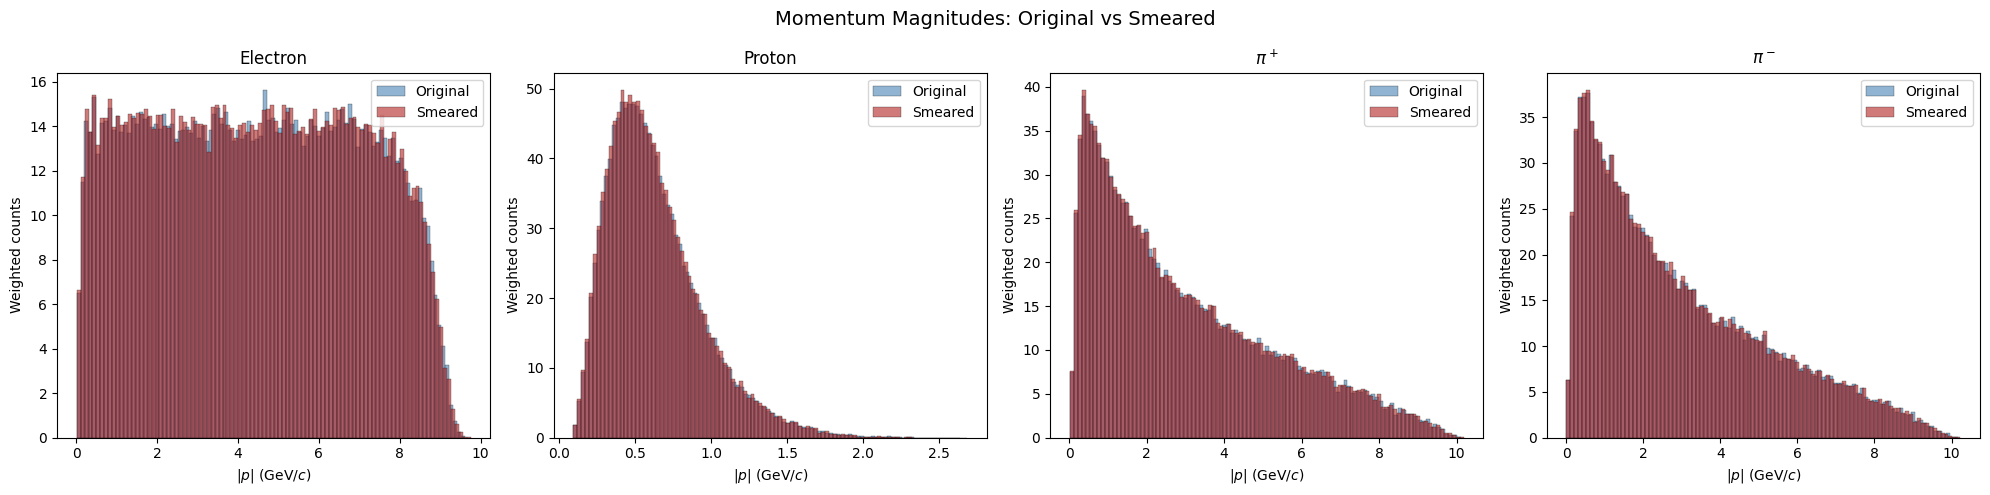

Saved smeared_momenta.png


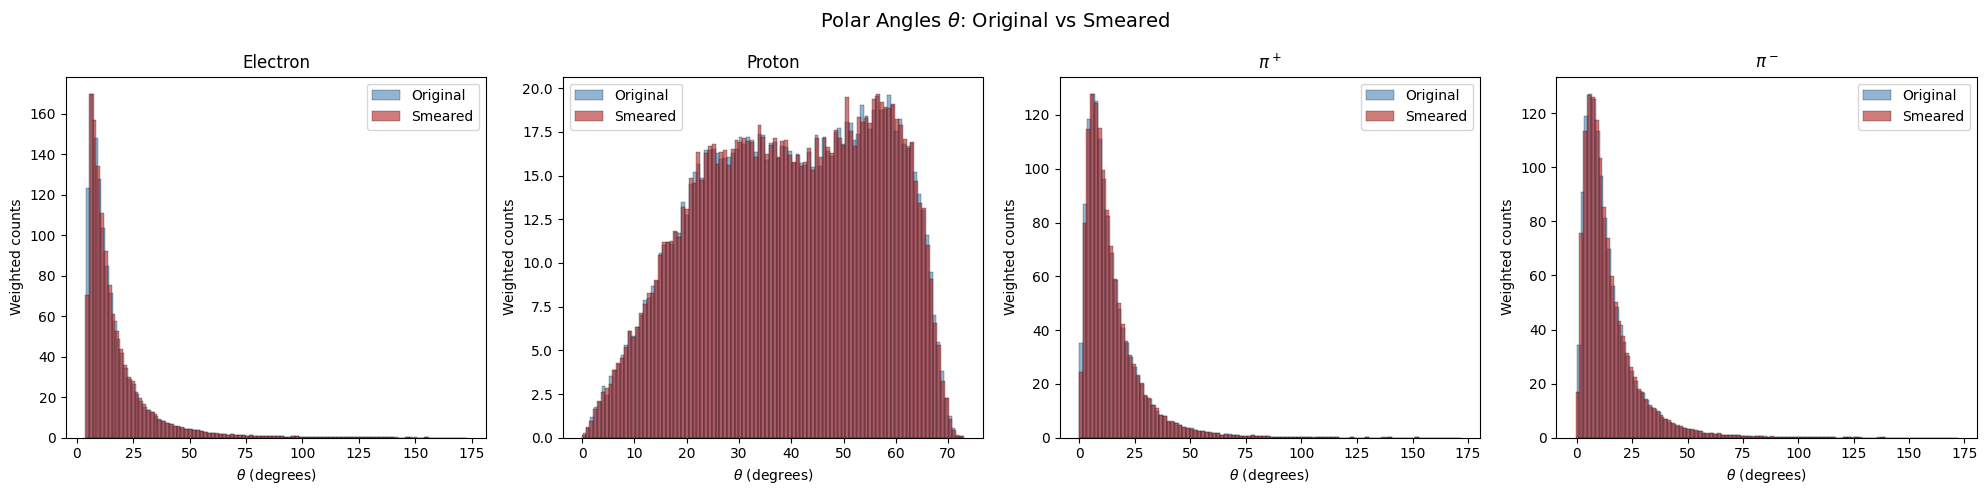

Saved smeared_polar_angles.png


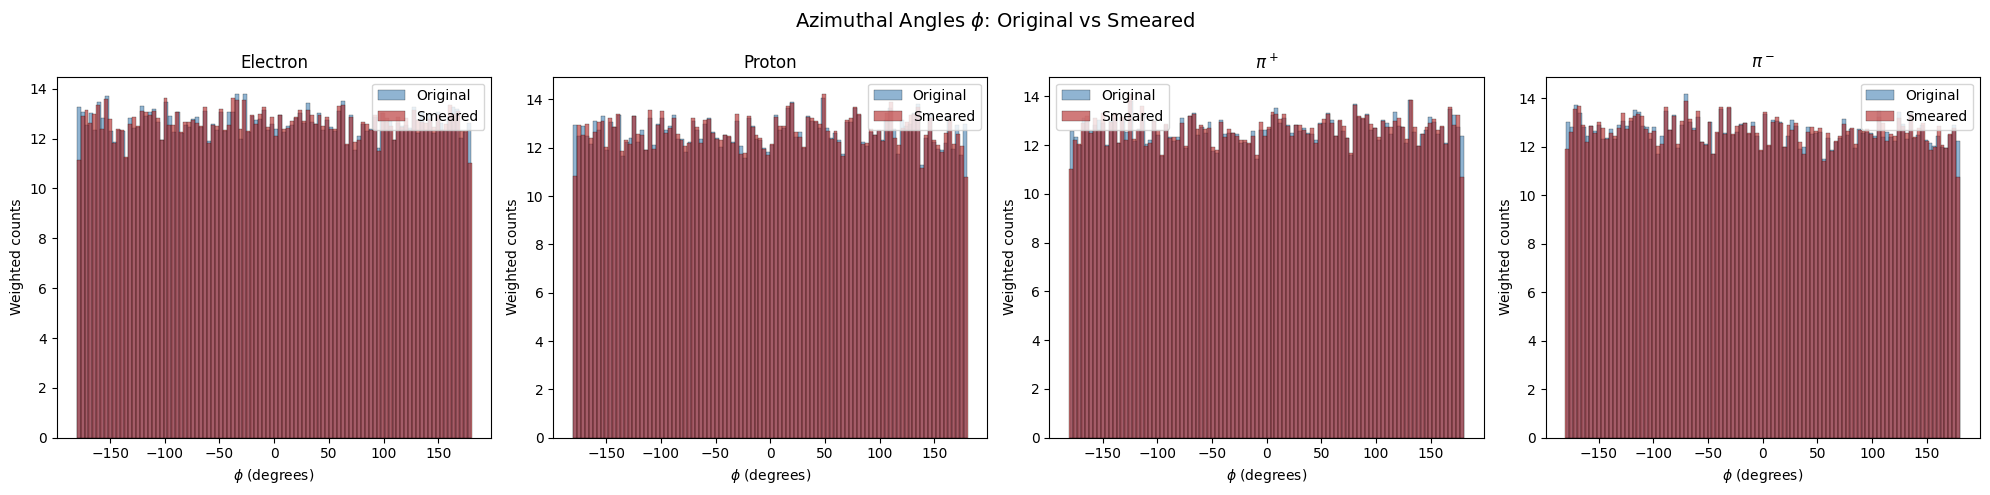

Saved smeared_azimuthal_angles.png


In [5]:
MOMENTUM_SMEARING_FRACTION = 0.01          # 1% Gaussian smearing on momentum
ANGLE_SMEARING_RAD         = 0.004         # 4 mrad Gaussian smearing on theta and phi
ANGLE_SMEARING_DEG         = math.degrees(ANGLE_SMEARING_RAD)  # convert to degrees

#smearing 
def smear_momentum(p):
    sigma = MOMENTUM_SMEARING_FRACTION * p
    smeared = random.gauss(p, sigma)
    return max(smeared, 0.0)  #prevent negative magnitude

def smear_angle(angle_deg):
    return random.gauss(angle_deg, ANGLE_SMEARING_DEG)

#apply the smearing to everything
def apply_smearing(data):
    particle_keys = ['electron', 'proton', 'pip', 'pim']
    smeared = {}
 
    for key in particle_keys:
        original = data[f'p_{key}']
        smeared[f'p_{key}'] = [smear_momentum(p) for p in original]
 
    for key in particle_keys:
        original = data[f'theta_{key}']
        smeared[f'theta_{key}'] = [smear_angle(t) for t in original]
 
    for key in particle_keys:
        original = data[f'phi_{key}']
        smeared[f'phi_{key}'] = [smear_angle(f) for f in original]
 
    #variables to transfer unchanged
    smeared['missing_masses_new'] = data['missing_masses_new']
    smeared['weights']            = data['weights']
    return smeared
 
 
#comparing plots
def plot_smearing_comparison(original, smeared):
    weights         = original['weights']
    particle_labels = ['Electron', 'Proton', '$\\pi^+$', '$\\pi^-$']
 
    #fig 1
    fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
    fig1.suptitle('Momentum Magnitudes: Original vs Smeared', fontsize=14)
    for ax, key, label in zip(
        axes1,
        ['p_electron', 'p_proton', 'p_pip', 'p_pim'],
        particle_labels
    ):
        ax.hist(original[key], bins=100, weights=weights,
                color='steelblue', edgecolor='black', linewidth=0.3,
                alpha=0.6, label='Original')
        ax.hist(smeared[key], bins=100, weights=weights,
                color='firebrick', edgecolor='black', linewidth=0.3,
                alpha=0.6, label='Smeared')
        ax.set_xlabel('$|p|$ (GeV/$c$)')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
        ax.legend()
    plt.tight_layout()
    plt.savefig('smeared_momenta.png', dpi=150)
    plt.show()
    print("Saved smeared_momenta.png")
 
    #fig 2
    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
    fig2.suptitle('Polar Angles $\\theta$: Original vs Smeared', fontsize=14)
    for ax, key, label in zip(
        axes2,
        ['theta_electron', 'theta_proton', 'theta_pip', 'theta_pim'],
        particle_labels
    ):
        ax.hist(original[key], bins=100, weights=weights,
                color='steelblue', edgecolor='black', linewidth=0.3,
                alpha=0.6, label='Original')
        ax.hist(smeared[key], bins=100, weights=weights,
                color='firebrick', edgecolor='black', linewidth=0.3,
                alpha=0.6, label='Smeared')
        ax.set_xlabel('$\\theta$ (degrees)')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
        ax.legend()
    plt.tight_layout()
    plt.savefig('smeared_polar_angles.png', dpi=150)
    plt.show()
    print("Saved smeared_polar_angles.png")
 
    #fig 3
    fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
    fig3.suptitle('Azimuthal Angles $\\phi$: Original vs Smeared', fontsize=14)
    for ax, key, label in zip(
        axes3,
        ['phi_electron', 'phi_proton', 'phi_pip', 'phi_pim'],
        particle_labels
    ):
        ax.hist(original[key], bins=100, weights=weights,
                color='steelblue', edgecolor='black', linewidth=0.3,
                alpha=0.6, label='Original')
        ax.hist(smeared[key], bins=100, weights=weights,
                color='firebrick', edgecolor='black', linewidth=0.3,
                alpha=0.6, label='Smeared')
        ax.set_xlabel('$\\phi$ (degrees)')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
        ax.legend()
    plt.tight_layout()
    plt.savefig('smeared_azimuthal_angles.png', dpi=150)
    plt.show()
    print("Saved smeared_azimuthal_angles.png")

#run the smearing (moment of truth mk. 3)
smeared_data = apply_smearing(data)
plot_smearing_comparison(data, smeared_data)

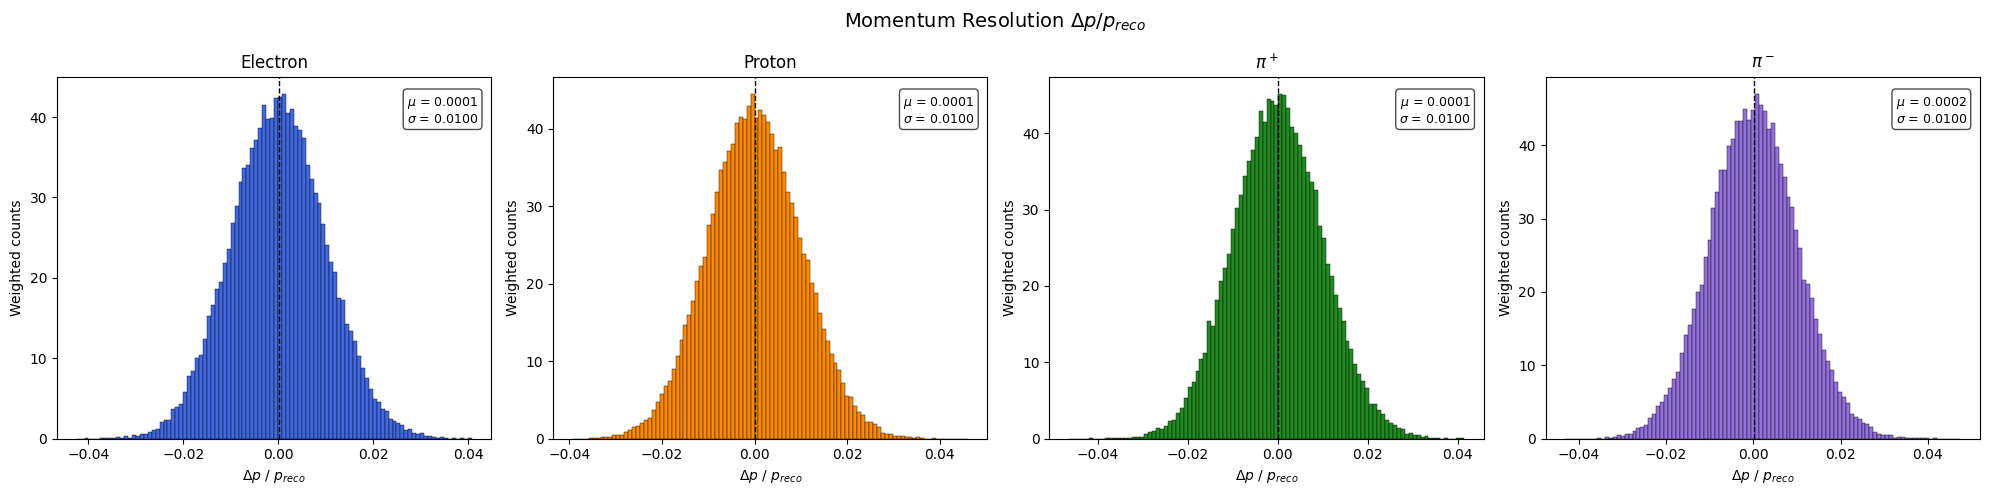

Saved momentum_resolution_distribution.png


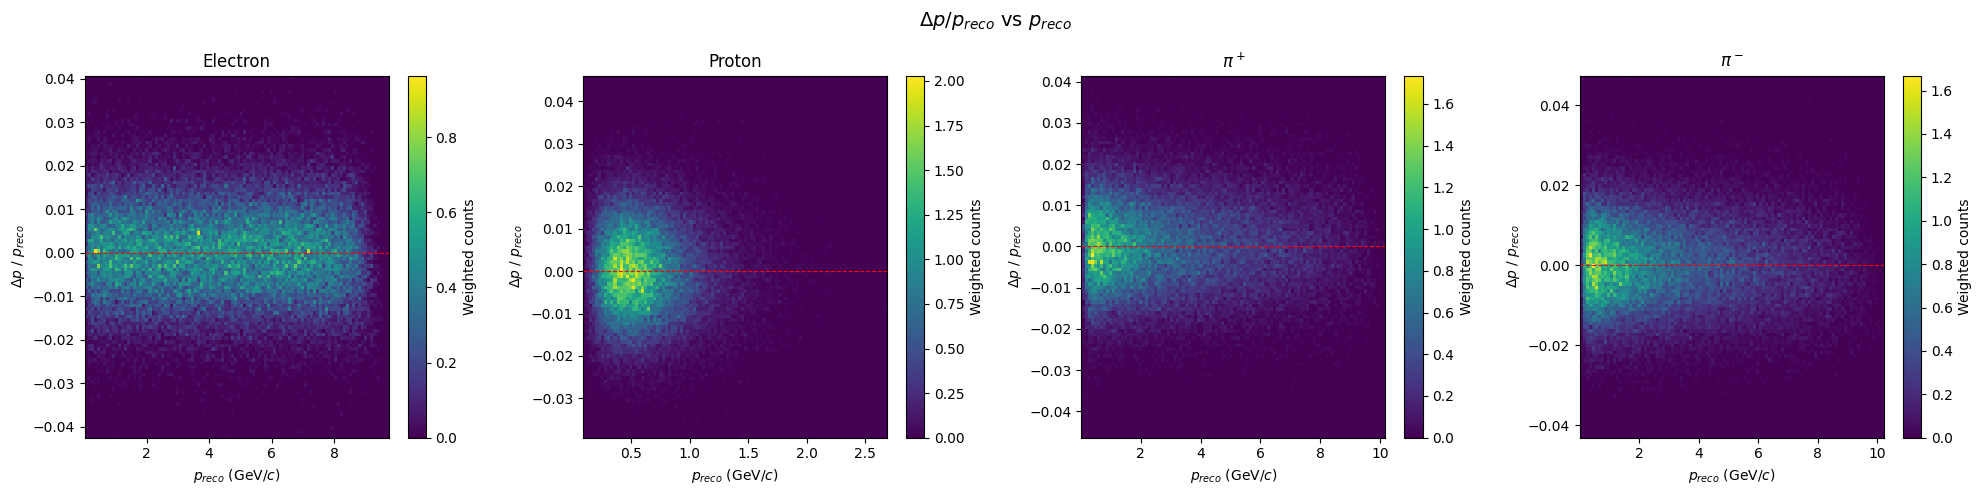

Saved momentum_resolution_2d.png


In [6]:
def compute_momentum_resolution(original, smeared):
    particle_keys   = ['electron', 'proton', 'pip', 'pim']
    resolution      = {}
    p_reco_out      = {}
    for key in particle_keys:
        p_gen  = original[f'p_{key}']
        p_reco = smeared[f'p_{key}']
        res    = []
        p_out  = []
        for pg, pr in zip(p_gen, p_reco):
            # Avoid division by zero
            if pr == 0.0:
                continue
            res.append((pg - pr) / pr)
            p_out.append(pr)
        resolution[key] = res
        p_reco_out[key] = p_out
    return resolution, p_reco_out
 
 
#plot 1
def plot_resolution_distribution(resolution, weights):
    particle_labels = ['Electron', 'Proton', '$\\pi^+$', '$\\pi^-$']
    particle_keys   = ['electron', 'proton', 'pip', 'pim']
    colors          = ['royalblue', 'darkorange', 'forestgreen', 'mediumpurple']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('Momentum Resolution $\\Delta p / p_{reco}$', fontsize=14)
    for ax, key, label, color in zip(axes, particle_keys, particle_labels, colors):
        res = resolution[key]
        
        #remove unused weights
        w = weights[:len(res)]
        ax.hist(res, bins=100, weights=w,
                color=color, edgecolor='black', linewidth=0.3)
        ax.set_xlabel('$\\Delta p \\ / \\ p_{reco}$')
        ax.set_ylabel('Weighted counts')
        ax.set_title(label)
 
        #annotate
        mean = np.mean(res)
        std  = np.std(res)
        ax.axvline(mean, color='black', linestyle='--', linewidth=1.0,
                   label=f'Mean: {mean:.4f}')
        ax.text(0.97, 0.95, f'$\\mu$ = {mean:.4f}\n$\\sigma$ = {std:.4f}',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout()
    plt.savefig('momentum_resolution_distribution.png', dpi=150)
    plt.show()
    print("Saved momentum_resolution_distribution.png")

#plot 2
def plot_resolution_2d(resolution, p_reco, weights):
    particle_labels = ['Electron', 'Proton', '$\\pi^+$', '$\\pi^-$']
    particle_keys   = ['electron', 'proton', 'pip', 'pim']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        '$\\Delta p / p_{reco}$ vs $p_{reco}$', fontsize=14)
    for ax, key, label in zip(axes, particle_keys, particle_labels):
        res  = resolution[key]
        pr   = p_reco[key]
        w    = weights[:len(res)]
        h = ax.hist2d(
            pr, res,
            bins=100,
            weights=w,
            cmap='viridis'
        )
        plt.colorbar(h[3], ax=ax, label='Weighted counts')
        ax.set_xlabel('$p_{reco}$ (GeV/$c$)')
        ax.set_ylabel('$\\Delta p \\ / \\ p_{reco}$')
        ax.set_title(label)
        # Reference line at zero resolution
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('momentum_resolution_2d.png', dpi=150)
    plt.show()
    print("Saved momentum_resolution_2d.png")

#run it (final time for now)
resolution, p_reco = compute_momentum_resolution(data, smeared_data)
weights = data['weights']
plot_resolution_distribution(resolution, weights)
plot_resolution_2d(resolution, p_reco, weights)

Smeared events reconstructed: 100000
Events processed : 100000
Events used      : 99964
Events skipped   : 36


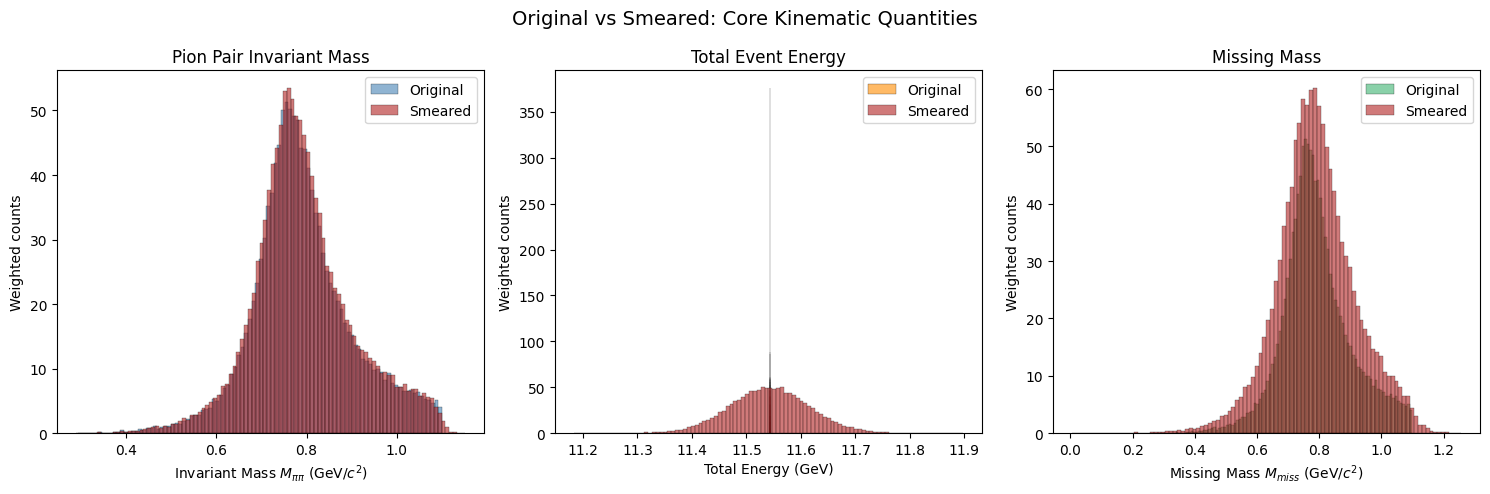

Saved smeared_kinematics.png


In [7]:
def reconstruct_smeared_events(all_events, smeared_data):
    #known masses
    mass_lookup = {
        PDG_ELECTRON : MASS_ELECTRON,
        PDG_PROTON   : MASS_PROTON,
        PDG_PIP      : MASS_PION,
        PDG_PIM      : MASS_PION,
        PDG_PI0      : MASS_PI0,
    }
    #index into smeared_data lists — one entry per valid event
    smeared_events = []
    smear_idx = 0
    for event in all_events:
        #identify particles again
        parts = identify_particles(event)
        #skip events that were skipped during smearing
        if parts['final_electron'] is None:
            continue
        if parts['final_proton'] is None:
            continue
        if len(parts['pions']) < 2:
            continue
        pip = None
        pim = None
        for pion in parts['pions']:
            if pion['pdg_id'] == PDG_PIP:
                pip = pion
            elif pion['pdg_id'] == PDG_PIM:
                pim = pion
        if pip is None or pim is None:
            continue
        #pull smeared values for this event from smeared_data
        p_e   = smeared_data['p_electron'][smear_idx]
        p_p   = smeared_data['p_proton'][smear_idx]
        p_pip = smeared_data['p_pip'][smear_idx]
        p_pim = smeared_data['p_pim'][smear_idx]
        t_e   = math.radians(smeared_data['theta_electron'][smear_idx])
        t_p   = math.radians(smeared_data['theta_proton'][smear_idx])
        t_pip = math.radians(smeared_data['theta_pip'][smear_idx])
        t_pim = math.radians(smeared_data['theta_pim'][smear_idx])
        ph_e   = math.radians(smeared_data['phi_electron'][smear_idx])
        ph_p   = math.radians(smeared_data['phi_proton'][smear_idx])
        ph_pip = math.radians(smeared_data['phi_pip'][smear_idx])
        ph_pim = math.radians(smeared_data['phi_pim'][smear_idx])
        smear_idx += 1
        #transfer to cartesian coordinates
        def to_cartesian(pmag, theta, phi):
            px = pmag * math.sin(theta) * math.cos(phi)
            py = pmag * math.sin(theta) * math.sin(phi)
            pz = pmag * math.cos(theta)
            return px, py, pz
        #creates a new list with the smeared p's found from the smeared spherical coordinates to replace generated p's
        def smeared_particle(original, pmag, theta, phi):
            px, py, pz = to_cartesian(pmag, theta, phi)
            mass       = mass_lookup.get(original['pdg_id'], original['mass'])
            energy     = math.sqrt(pmag**2 + mass**2)
            p          = copy.copy(original)
            p['px']    = px
            p['py']    = py
            p['pz']    = pz
            p['energy']= energy
            return p

        #create smeared particle list
        smeared_particles = [
            smeared_particle(parts['final_electron'], p_e,   t_e,   ph_e),
            smeared_particle(parts['final_proton'],   p_p,   t_p,   ph_p),
            smeared_particle(pip,                     p_pip, t_pip, ph_pip),
            smeared_particle(pim,                     p_pim, t_pim, ph_pim),
        ]

        #create list of smeared events
        smeared_event = copy.copy(event)
        smeared_event['particles'] = smeared_particles
        smeared_events.append(smeared_event)

    print(f"Smeared events reconstructed: {len(smeared_events)}")
    return smeared_events

#smeared plots
def plot_smeared_kinematics(original_results, smeared_results):
    orig_m,  orig_e,  orig_mm,  orig_w  = original_results
    smear_m, smear_e, smear_mm, smear_w = smeared_results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Original vs Smeared: Core Kinematic Quantities', fontsize=14)

    #plot 1
    axes[0].hist(orig_m, bins=100, weights=orig_w,
                 color='steelblue', alpha=0.6, edgecolor='black',
                 linewidth=0.3, label='Original')
    axes[0].hist(smear_m, bins=100, weights=smear_w,
                 color='firebrick', alpha=0.6, edgecolor='black',
                 linewidth=0.3, label='Smeared')
    axes[0].set_xlabel('Invariant Mass $M_{\\pi\\pi}$ (GeV/$c^2$)')
    axes[0].set_ylabel('Weighted counts')
    axes[0].set_title('Pion Pair Invariant Mass')
    axes[0].legend()

    #plot 2
    axes[1].hist(orig_e, bins=100, weights=orig_w,
                 color='darkorange', alpha=0.6, edgecolor='black',
                 linewidth=0.3, label='Original')
    axes[1].hist(smear_e, bins=100, weights=smear_w,
                 color='firebrick', alpha=0.6, edgecolor='black',
                 linewidth=0.3, label='Smeared')
    axes[1].set_xlabel('Total Energy (GeV)')
    axes[1].set_ylabel('Weighted counts')
    axes[1].set_title('Total Event Energy')
    axes[1].legend()

    #plot 3
    axes[2].hist(orig_mm, bins=100, weights=orig_w,
                 color='mediumseagreen', alpha=0.6, edgecolor='black',
                 linewidth=0.3, label='Original')
    axes[2].hist(smear_mm, bins=100, weights=smear_w,
                 color='firebrick', alpha=0.6, edgecolor='black',
                 linewidth=0.3, label='Smeared')
    axes[2].set_xlabel('Missing Mass $M_{miss}$ (GeV/$c^2$)')
    axes[2].set_ylabel('Weighted counts')
    axes[2].set_title('Missing Mass')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('smeared_kinematics.png', dpi=150)
    plt.show()
    print("Saved smeared_kinematics.png")

#run smeared kinematics
smeared_events = reconstruct_smeared_events(all_events, smeared_data)
smeared_results = process_events(smeared_events)
original_results = (pion_inv_masses, total_energies, missing_masses, weights)
plot_smeared_kinematics(original_results, smeared_results)